In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from _helper_functions import *

In [2]:
# newly tested variants forming the test set
testlistdf=pd.read_csv('variant-labels.txt',sep='\t')
testlistdf['name']=[i.replace('OSL','ORL') for i in testlistdf['name']]
testlist=[i for i in testlistdf['name'].tolist()]

In [3]:
c2f={
    'b6.5':list,
    'a6.5':list,
    'a6.7 PSV':list,
    'a6.7 ASV':list,
    'A-line ASV/PSV':list,
    'Trunk Lateral Cell':list,
    'Endoderm (A)':list,
    'Primary Notochord':list,    
    'VNC + PSV':list,
    'LNC':list,
    'Endoderm (B)':list,
    'Secondary Notochord':list,
    'Mesenchyme':list,
    'Epidermis (a)':list,
    'Epidermis (b)':list,
    'Heart':list,
    'Muscle A/B':list,
    'Germ Cell':list,
 }

sdf=pd.read_csv('S12-all-annotations_percent.csv').set_index('col_celltype')
ylabel='pct-cells'

sdf=pd.read_csv('S12-all-annotations_value.csv').set_index('col_celltype')
ylabel='exp-cells'

sdf.columns=[c.split('(')[0] for c in sdf.columns]
sdf=sdf.transpose().reset_index()
sdf=sdf.merge(testlistdf,left_on='index',right_on='name')
sdf=sdf.loc[sdf['index'].isin(testlist),:]

sdf=sdf.groupby('prediction').agg(c2f)

c2v={c:[] for c in ['tissue','value','Syntax']}
for tis in c2f:
    for syn in ['moderate','robust']:
        for val in sdf.at[syn,tis]:
            
            c2v['tissue'].append(tis)
            c2v['value'].append(val)
            c2v['Syntax'].append(syn)

    
plotdf=pd.DataFrame(c2v)


In [4]:
mods=plotdf['Syntax']=='moderate'
robs=plotdf['Syntax']=='robust'
ines=plotdf['Syntax']=='inert'

Text(0.5, 6.583333333333323, '')

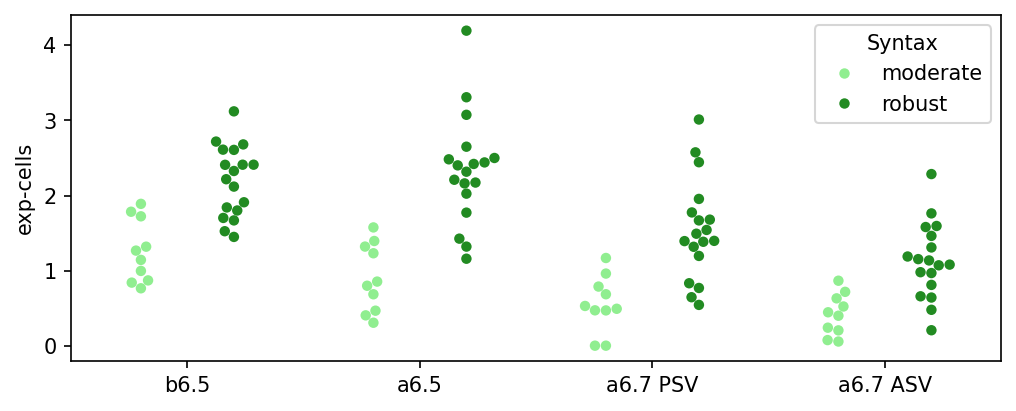

In [5]:
order=[ 
'b6.5',
'a6.5',
'a6.7 PSV',
'a6.7 ASV',
]

for oi in order:
    
    thisdf=plotdf.loc[plotdf['tissue']==oi,:]
    _,p = stats.ttest_ind(thisdf.loc[mods,'value'], 
                                thisdf.loc[robs,'value'])
    
    
fig,ax=quickfig(8,3)
sns.swarmplot(data=plotdf,x='tissue',y='value',hue='Syntax',order=order,dodge=True,palette=['lightgreen','forestgreen'])
ax.set_ylabel(ylabel)
ax.set_xlabel('')

In [6]:
robs=plotdf['Syntax']=='robust'
endo=(plotdf['tissue']=='Endoderm (A)')      & robs
noto=(plotdf['tissue']=='Primary Notochord')  & robs
vnps=(plotdf['tissue']=='VNC + PSV')          & robs
lnc =(plotdf['tissue']=='LNC')                & robs

_,p=stats.ttest_ind(plotdf.loc[endo,'value'],plotdf.loc[vnps,'value'])
print('endoderm vs vnc+psv',round(p,3))

# _,p=stats.mannwhitneyu(plotdf.loc[endo,'value'],plotdf.loc[lnc,'value'])
_,p=stats.ttest_ind(plotdf.loc[endo,'value'],plotdf.loc[lnc,'value'])

print('endoderm vs lnc',round(p,3))

_,p=stats.ttest_ind(plotdf.loc[noto,'value'],plotdf.loc[vnps,'value'])
print('prim noto vs vnc+psv',round(p,3))

_,p=stats.ttest_ind(plotdf.loc[noto,'value'],plotdf.loc[lnc,'value'])
print('prim noto vs lnc',round(p,3))

endoderm vs vnc+psv 0.005
endoderm vs lnc 0.02
prim noto vs vnc+psv 0.011
prim noto vs lnc 0.037


/var/folders/w_/c5c_656n15798dlm00g7fp6r0000gn/T/ipykernel_4552/2534378153.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=plotdf.loc[plotdf['Syntax']=='robust',:],x='tissue',y='value',order=order,dodge=True,palette=['forestgreen'])
/var/folders/w_/c5c_656n15798dlm00g7fp6r0000gn/T/ipykernel_4552/2534378153.py:9: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.swarmplot(data=plotdf.loc[plotdf['Syntax']=='robust',:],x='tissue',y='value',order=order,dodge=True,palette=['forestgreen'])


Text(93.95833333333333, 0.5, 'exp-cells')

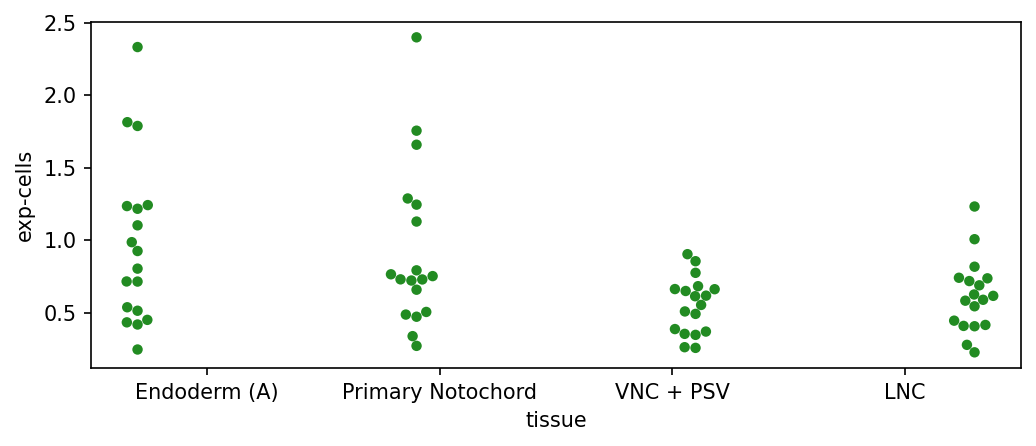

In [7]:
order=[ 
'Endoderm (A)',
'Primary Notochord',
'VNC + PSV',
'LNC',    
]

fig,ax=quickfig(8,3)
sns.swarmplot(data=plotdf.loc[plotdf['Syntax']=='robust',:],x='tissue',y='value',order=order,dodge=True,palette=['forestgreen'])
ax.set_ylabel(ylabel)
